In [1]:
import pandas as pd
from utils.misc import cols_to_front
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import TruncatedSVD
from sklearn.decomposition import PCA
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import os
from sklearn.feature_extraction.text import TfidfTransformer
from utils.misc import cols_to_front
import yaml
with open('config/config.yaml', 'r') as file:
    config = yaml.safe_load(file)

# Ensure output dir exists
output_dir = config['output_dir']
os.makedirs(output_dir, exist_ok=True)

In [2]:
# Import data
merged_df = pd.read_csv('data/merged_ai_descriptors_clean.csv')
df1 = pd.read_csv('data/merged_ai_descriptors_dummies_filtered.csv')

In [3]:
# Get column names
desc = [
    c for c in df1.columns
    if c != "Nom scientifique" and "cat_" not in c and 'category' not in c and 'db' not in c
]
desc_og = desc
cat_cols = [c for c in df1.columns if "cat_" in c]
name = "Nom scientifique"

In [4]:
merged_df['category'] = merged_df['sub_category'].copy()

In [5]:
df1 = df1.merge(
    merged_df[["Nom scientifique", "category", "db"]].drop_duplicates("Nom scientifique"),
    on="Nom scientifique",
    how="left",
    validate="many_to_one"  # optional but recommended
)

df1 = cols_to_front(df1, ['Nom scientifique', 'category'])

df1_og = df1.copy(deep=True)
df1.head()

,Nom scientifique,category,acid,airy,anise,apple,aroma,astringent,bean,beef,...,cat_beverage,cat_fruit,cat_fungus,cat_grains,cat_nuts,cat_plant,cat_prepared food,cat_tuber,cat_vegetable,db
0,Macrocystis pyrifera,plant,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,local
1,Palmaria palmata,plant,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,local
2,Porphyra perforata,plant,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,local
3,Porphyra abbottae,plant,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,local
4,Porphyra torta,plant,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,local


# Overview

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count number of columns > 0 for each row
row_nonzero_counts = df1[desc].sum(axis=1)

if config['show_plot']:
    # Plot histogram
    plt.figure(figsize=(10, 6))
    sns.histplot(row_nonzero_counts, bins=20)
    plt.xlabel('Number descriptors', fontsize=12)
    plt.ylabel('Number of ingredients', fontsize=12)
    plt.title('Number of descriptors per ingredients', fontsize=14)
    plt.grid(False)

    save_path = os.path.join("output", "stats_nbr_descriptor_per_ing.png")
    plt.savefig(save_path, dpi=300, bbox_inches='tight')

In [7]:
# Number of ingredient where each ai descriptor is used
non_null_counts = df1[desc].sum()

if config['show_plot']:
    # Plot histogram
    plt.figure(figsize=(10, 6))
    sns.histplot(non_null_counts, bins=20)
    plt.xlabel('Number of ingredients', fontsize=12)
    plt.ylabel('Number of descriptors', fontsize=12)
    plt.title('Number of descriptor per ingredient', fontsize=14)
    plt.grid(False)

    save_path = os.path.join("output", "stats_nbr_of ingredients_per_descriptor.png")
    plt.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()

In [8]:
# Number of ingredient where each ai descriptor is used
non_null_counts.sort_values(ascending=False).head(20)

sweet       957
earth       716
nut         453
fresh       402
bitter      365
savory      288
tang        277
delicate    265
aroma       264
grass       252
butter      243
floral      234
umami       227
cream       219
spicy       208
fruit       207
tender      192
vegetal     192
crisp       190
juice       180
dtype: int64

In [9]:
# Number of ingredient where each ai descriptor is used
cat_flavors = {}
cat_flav10 = {}
df2 = df1[desc+["category"]].groupby('category').sum()

for cat in df2.index.unique():
    cat_flavors[cat] =  df2.loc[cat].sort_values(ascending=False)
    cat_flav10[cat] = cat_flavors[cat].head(10)


# Category definition

## Custom categories

In [10]:
lexicon = {'plant': 'plant',
 'animal product': 'animal product',
 'fungus': 'fungus',
 'beverage': 'beverage',
 None: None,
 'vegetable': 'vegetable',
 'dish': 'dish',
 'vegetable-root': 'root',
 'fruit': 'fruit',
 'herb': 'herb',
 'additive': 'additive',
 'cereal': 'cereal',
 'flower': 'flower',
 'bakery': 'bakery',
 'beverage alcoholic': 'beverage alcoholic',
 'beverage caffeinated': 'beverage',
 'maize': 'cereal',
 'dairy': 'dairy',
 'essential oil': 'essential oil',
 'berry': 'berry',
 'seafood': 'seafood',
 'fish': 'seafood',
 'fruit-berry': 'berry',
 'fruit citrus': 'fruit citrus',
 'fruit essence': 'essential oil',
 'meat': 'animal product',
 'nut': 'nut',
 'seed': 'nut',
 'legume': 'legume',
 'plant derivative': 'plant derivative',
 'spice': 'spice',
 'cabbage': 'vegetable',
 'vegetable root': 'root',
 'vegetable fruit': 'vegetable fruit',
 'gourd': 'gourd',
 'vegetable stem': 'vegetable',
 'vegetable tuber': 'root'}

lexicon_og = {cat: cat for cat in df1['category'].dropna().unique()}  # make og dict

In [11]:
df1['category'] = df1['category'].map(lexicon).fillna(df1['category'])

In [12]:
cat_to_drop = ['animal product','dish', 'bakery', 'beverage alcoholic', 'dairy' ,'seafood' ]
df1 = df1[~df1['category'].isin(cat_to_drop)]

## FoodDB categories

In [13]:
foodb = pd.read_csv("data/foodb_food_cat_list.csv")

foodb['name'] = foodb['name'].str.lower()
group_dict = foodb.set_index('name')['food_group'].to_dict()
subgroup_dict = foodb.set_index('name')['food_subgroup'].to_dict()

In [14]:
# df1['Nom scientifique'] = df1['Nom scientifique'].str.lower()
# df1['category'] = df1['Nom scientifique'].map(group_dict).fillna(df1['category'])

# df1['category'] = df1['category'].str.lower()

In [15]:
# cat = 'plant derivative'
# df1.loc[df1['category'] == cat]

In [16]:
# df1 = df1.loc[df1['db'] != 'local']

In [17]:
# df1 = df1.loc[df1['db'] == 'local']
# df1.loc[df1['category'] == 'fruit']

In [18]:
# Keep only categories that appear at least 3 times
category_counts = df1['category'].value_counts()
df1 = df1[df1['category'].isin(category_counts[category_counts >= 3].index)]

In [19]:
if config['show_plot']:
    # --- Build feature matrix (drop identifiers and one-hot category columns) ---
    df_features = df1[desc]
    df_features = df_features.drop(columns=[c for c in df_features.columns if "cat_" in c], errors='ignore')

    # Keep only numeric columns (t-SNE requires numbers)
    df_features = df_features.select_dtypes(include=[np.number])

    # Handle NaNs
    df_features = df_features.fillna(0.0)

    # Optional: scale features (recommended for t-SNE)
    X = StandardScaler().fit_transform(df_features.values)

    # --- Align categories from merged_df to df1 rows ---
    name_series = df1['Nom scientifique']
    categories = df1['category']

    # --- Fit t-SNE ---
    tsne = TSNE(
        n_components=2,
        perplexity=min(30, max(5, (len(df_features) - 1) // 3)),  # decent auto heuristic
        learning_rate='auto',
        init='pca',
        metric='euclidean',
        random_state=42,
    )
    tsne_embedding = tsne.fit_transform(X)

    # --- Prepare DataFrame for plotting ---
    tsne_df = pd.DataFrame(tsne_embedding, columns=['tSNE1', 'tSNE2'])
    tsne_df['category'] = categories.values

    # --- Plot ---
    plt.figure(figsize=(12, 8))
    sns.scatterplot(
        data=tsne_df,
        x='tSNE1',
        y='tSNE2',
        hue='category',
        s=50,
        alpha=0.8
    )
    plt.title('t-SNE projection of Ingredient Categories', fontsize=18)
    plt.xlabel('tSNE1', fontsize=14)
    plt.ylabel('tSNE2', fontsize=14)
    plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


In [20]:
def jaccard_similarity_matrix(df_bin: pd.DataFrame) -> pd.DataFrame:
    """
    Compute Jaccard similarity for all pairs of rows in a binary DataFrame.
    """
    X = df_bin.to_numpy(dtype=int)
    n = X.shape[0]

    sim = np.zeros((n, n), dtype=float)

    for i in range(n):
        for j in range(i, n):
            intersection = np.logical_and(X[i], X[j]).sum()
            union = np.logical_or(X[i], X[j]).sum()
            sim_val = intersection / union if union != 0 else 0
            sim[i, j] = sim_val
            sim[j, i] = sim_val

    return pd.DataFrame(sim, index=df_bin.index, columns=df_bin.index)

# Compute Jaccard similarity matrix
jaccard_sim = jaccard_similarity_matrix(df1[desc])

# Average similarity per category
jaccard_sim['category'] = df1['category'].values
jaccard_sim_mean = jaccard_sim.groupby('category').mean()
jaccard_sim_mean = jaccard_sim_mean.T
jaccard_sim_mean['category'] = df1['category'].values
jaccard_sim_mean = jaccard_sim_mean.groupby('category').mean()

# if config['show_plot']:
#     plt.figure(figsize=(10, 8))
#     sns.heatmap(jaccard_sim_mean, cmap="coolwarm", vmin=0, vmax = 0.5)
#     plt.title("Mean Jaccard Similarity of ingredients in each category")
#     plt.show()


In [21]:
if config['show_plot']:
    # --- Cluster the category-level similarity matrix ---
    sns.clustermap(
        jaccard_sim_mean,
        cmap="coolwarm",
        vmin=0, vmax=0.5,
        method="ward",
        metric="euclidean",
        figsize=(10, 8)
    )

    plt.suptitle("Clustered Jaccard Similarity of Ingredient Categories", y=1.02)
    plt.show()

In [22]:
cat = 'seafood'
df1.loc[df1['category'] == cat]
print(df1.loc[df1['category'] == cat]['Nom scientifique'].values)

[]


In [23]:
df1['category'].value_counts()

category
plant               113
fruit                90
root                 61
herb                 57
vegetable            52
essential oil        43
berry                43
additive             32
cereal               31
nut                  26
fungus               25
spice                25
legume               23
beverage             21
plant derivative     20
flower               12
fruit citrus         10
gourd                 7
vegetable fruit       4
Name: count, dtype: int64

# Dimensionality reduction

## SVD

In [24]:
# --- Copy + select one-hot columns ---
df = df1.copy(deep=True)
X = df[desc].to_numpy()   # PCA expects dense (numpy array)
cols = df[desc].columns
n_components = config['n_dim']

In [25]:
# SVD
if config['reduce_dim_method'] == 'svd':
    # --- Truncated SVD ---    
    svd = TruncatedSVD(n_components=n_components, random_state=42)
    if config['idf']:    #IDF Seems to lead to worst fitting of dims by SVD
        tfidf = TfidfTransformer(norm=None, use_idf=True, smooth_idf=True, sublinear_tf=False)
        X = tfidf.fit_transform(X)  # stays sparse
    X_svd = svd.fit_transform(X)

    if config['reduce_dim'] == True:
        # --- Replace desc columns with SVD components in df ---
        dim_cols = [f"svd_{i+1:03d}" for i in range(n_components)]
        df.drop(columns=desc, inplace=True)
        df[dim_cols] = X_svd
        df1_dim_reduced = df.copy(deep=True)

C:\Users\jpcle8\AppData\Local\Temp\ipykernel_26472\1425643057.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[dim_cols] = X_svd
C:\Users\jpcle8\AppData\Local\Temp\ipykernel_26472\1425643057.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[dim_cols] = X_svd


## PCA

In [26]:
# PCA
if config['reduce_dim_method'] == 'pca':
    # --- Optional scaling (recommended for PCA) ---
    # For one-hot/binary features, scaling is optional, but PCA often behaves better with scaling.
    if config.get("pca_scale", True):
        scaler = StandardScaler(with_mean=True, with_std=True)
        X = scaler.fit_transform(X)

    # --- PCA (pick n components) ---
    pca = PCA(n_components=n_components, random_state=42)
    X_pca = pca.fit_transform(X)

    if config["reduce_dim"] == True:
        # --- Replace desc columns with PCA components in df ---
        dim_cols = [f"pca_{i+1:03d}" for i in range(n_components)]
        df.drop(columns=desc, inplace=True)
        df[dim_cols] = X_pca
        df1_dim_reduced = df.copy(deep=True)

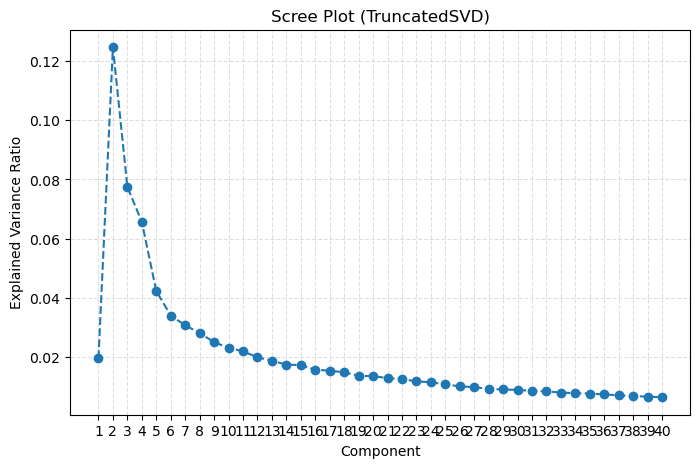

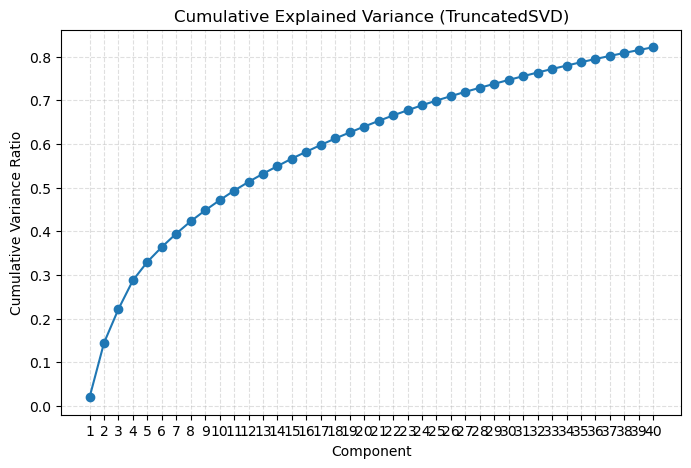

In [27]:
# --- Scree plot ---
if config["reduce_dim_method"] == "svd":
    model = svd
    method_label = "TruncatedSVD"
elif config["reduce_dim_method"] == "pca":
    model = pca
    method_label = "PCA"
else:
    raise ValueError(f"Unknown reduce_dim_method: {config['reduce_dim_method']} (expected 'svd' or 'pca')")

# Both PCA and TruncatedSVD provide explained_variance_ratio_
explained_var = model.explained_variance_ratio_

k = min(config["scree_max_dim"], len(explained_var))
dims = np.arange(1, k + 1)

os.makedirs("output", exist_ok=True)

# --- Scree plot ---
plt.figure(figsize=(8, 5))
plt.plot(dims, explained_var[:k], marker="o", linestyle="--")
plt.title(f"Scree Plot ({method_label})")
plt.xlabel("Component")
plt.ylabel("Explained Variance Ratio")
plt.xticks(dims)
plt.grid(True, linestyle="--", alpha=0.4)

save_path = os.path.join("output", f"scree_plot_{method_label}.png")
plt.savefig(save_path, dpi=config.get("dpi", 300), bbox_inches="tight")
if config.get("show_plot", False):
    plt.show()
# plt.close()

# --- Cumulative explained variance ---
plt.figure(figsize=(8, 5))
plt.plot(dims, np.cumsum(explained_var[:k]), marker="o")
plt.title(f"Cumulative Explained Variance ({method_label})")
plt.xlabel("Component")
plt.ylabel("Cumulative Variance Ratio")
plt.xticks(dims)
plt.grid(True, linestyle="--", alpha=0.4)

save_path = os.path.join("output", f"scree_plot_cum_{method_label}.png")
plt.savefig(save_path, dpi=config.get("dpi", 300), bbox_inches="tight")
if config.get("show_plot", False):
    plt.show()


## Save component top features

In [28]:
# Get features of top components
if config["reduce_dim_method"] == "pca":
    loadings = pd.DataFrame(pca.components_.T, columns=[f"PC{i+1}" for i in range(pca.n_components_)], index=cols)
if config["reduce_dim_method"] == "svd":
    loadings = pd.DataFrame(svd.components_.T, columns=[f"SVD{i+1}" for i in range(svd.n_components)], index=desc)

if 'loadings' in globals():
    top_features = {}

    for pc in loadings.columns[:20]:
        top10 = (
            loadings[pc]
            .nlargest(10)               # top 10
        )
        top_features[pc] = top10.index.tolist()

    # Print nicely
    for pc, features in top_features.items():
        print(f"{pc} top 10 features: {features}")

    # pc_theme = ["fruity", "earthy", "savory", "creamy", "Sour", "Spicy", "Toasted", "Oceanic", "Floral", "bright"]


SVD1 top 10 features: ['sweet', 'earth', 'bitter', 'nut', 'fresh', 'aroma', 'grass', 'floral', 'vegetal', 'tang']
SVD2 top 10 features: ['tang', 'tart', 'fruit', 'juice', 'fresh', 'floral', 'citrus', 'aroma', 'acid', 'bright']
SVD3 top 10 features: ['aroma', 'spicy', 'herb', 'bitter', 'pungent', 'pepper', 'wood', 'resin', 'citrus', 'pine']
SVD4 top 10 features: ['fresh', 'grass', 'crisp', 'vegetal', 'green', 'bitter', 'astringent', 'tender', 'mineral', 'water']
SVD5 top 10 features: ['tang', 'bitter', 'savory', 'umami', 'salt', 'tart', 'astringent', 'mineral', 'brine', 'vegetal']
SVD6 top 10 features: ['astringent', 'grass', 'bitter', 'nut', 'tart', 'sour', 'starch', 'fruit', 'toast', 'malty']
SVD7 top 10 features: ['wood', 'pine', 'astringent', 'resin', 'herb', 'citrus', 'umami', 'fresh', 'smoke', 'mineral']
SVD8 top 10 features: ['floral', 'vegetal', 'green', 'honey', 'bitter', 'mineral', 'grass', 'tropical', 'salt', 'brine']
SVD9 top 10 features: ['bitter', 'cream', 'citrus', 'aroma

In [29]:
# saving
# ---- settings ----
top_n = 10
use_first_k_pcs = 20  # adjust as needed

# ---- pick model (PCA preferred if both exist) ----
if "pca" in globals() and hasattr(pca, "components_") and hasattr(pca, "explained_variance_ratio_"):
    model = pca
    prefix = "PC"
elif "svd" in globals() and hasattr(svd, "components_") and hasattr(svd, "explained_variance_ratio_"):
    model = svd
    prefix = "SVD"
else:
    raise NameError("Neither a fitted `pca` nor a fitted `svd` was found in globals().")

# ---- build loadings if not already defined ----
# Assumes you have `cols` (descriptor names). If not, fall back to `desc`.
if "loadings" not in globals() or loadings is None:
    feat_names = cols if "cols" in globals() else desc_og
    loadings = pd.DataFrame(
        model.components_.T,
        columns=[f"{prefix}{i+1}" for i in range(model.n_components)],
        index=feat_names,
    )

# ---- extract top features ----
pcs = loadings.columns[:use_first_k_pcs]
top_features = {pc: loadings[pc].nlargest(top_n).index.tolist() for pc in pcs}

top10_wide = pd.DataFrame.from_dict(top_features, orient="index")
top10_wide.index.name = prefix
top10_wide.columns = [f"Top{i}" for i in range(1, top_n + 1)]

# ---- add explained variance ----
explained_var = pd.Series(
    model.explained_variance_ratio_,
    index=[f"{prefix}{i+1}" for i in range(model.n_components)],
    name="explained_variance",
)

top10_wide["explained_variance (%)"] = explained_var.loc[top10_wide.index].values * 100
top10_wide = cols_to_front(top10_wide, ["explained_variance (%)"])

# ---- save ----
os.makedirs("output", exist_ok=True)
save_path = os.path.join("output", f"top{top_n}_features_wide_with_variance_{prefix}.xlsx")
top10_wide.to_excel(save_path)

print(f"✅ Saved with explained variance ({prefix}): {save_path}")

✅ Saved with explained variance (SVD): output\top10_features_wide_with_variance_SVD.xlsx


In [30]:
# Plot data on new dims
if config['show_plot']:
    # Manually choose which components to plot (1-indexed)
    pc_a = 1
    pc_b = 2

    # --- Prepare data ---
    X = df1[desc].copy()          # can be sparse or dense
    categories = df1["category"]

    # Fix index
    i, j = pc_a - 1, pc_b - 1

    # --- Use existing PCA/SVD if present, otherwise fit SVD ---
    if "pca" in globals() and hasattr(pca, "components_"):
        model = pca
        pcs = model.transform(X)  # assumes X preprocessing matches how pca was fit
        prefix = "PC"
    elif "svd" in globals() and hasattr(svd, "components_"):
        model = svd
        pcs = model.transform(X)
        prefix = "SVD"
    else:
        n_components = max(100, pc_a, pc_b)
        svd = TruncatedSVD(n_components=n_components, random_state=42)
        pcs = svd.fit_transform(X)
        model = svd
        prefix = "SVD"

    c1, c2 = pcs[:, i], pcs[:, j]
    xvar = model.explained_variance_ratio_[i] * 100
    yvar = model.explained_variance_ratio_[j] * 100

    # --- Plot colored by category ---
    plt.figure(figsize=(8, 7))
    for cat in categories.unique():
        mask = (categories == cat).to_numpy()
        plt.scatter(c1[mask], c2[mask], label=cat, alpha=0.8)

    plt.xlabel(f"{prefix}{pc_a} ({xvar:.2f}% var)")
    plt.ylabel(f"{prefix}{pc_b} ({yvar:.2f}% var)")
    plt.title(f"{prefix} Scatter Plot ({prefix}{pc_a} vs {prefix}{pc_b}) colored by category")

    plt.axhline(0, color="grey", linewidth=0.8)
    plt.axvline(0, color="grey", linewidth=0.8)
    plt.legend(title="Category", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()


In [31]:
# # MCA - not ideal for one-hot encoded data with multiple labels like ours
# import prince


In [32]:
if config['reduce_dim'] == True:
    desc = dim_cols  # update desc to point to new SVD columns
    df1 = df1_dim_reduced.copy(deep=True)

# Classification accuracy

In [33]:
def jaccard_similarity_matrix(df_bin: pd.DataFrame) -> pd.DataFrame:
    """
    Compute Jaccard similarity for all pairs of rows in a binary DataFrame.
    """
    X = df_bin.to_numpy(dtype=int)
    n = X.shape[0]

    sim = np.zeros((n, n), dtype=float)

    for i in range(n):
        for j in range(i, n):
            intersection = np.logical_and(X[i], X[j]).sum()
            union = np.logical_or(X[i], X[j]).sum()
            sim_val = intersection / union if union != 0 else 0
            sim[i, j] = sim_val
            sim[j, i] = sim_val

    return pd.DataFrame(sim, index=df_bin.index, columns=df_bin.index)

# Compute Jaccard similarity matrix
jaccard_sim = jaccard_similarity_matrix(df1[desc])

# Average similarity per category
jaccard_sim['category'] = df1['category'].values
jaccard_sim_mean = jaccard_sim.groupby('category').mean()
jaccard_sim_mean = jaccard_sim_mean.T
jaccard_sim_mean['category'] = df1['category'].values
jaccard_sim_mean = jaccard_sim_mean.groupby('category').mean()



# plt.figure(figsize=(10, 8))
# sns.heatmap(jaccard_sim_mean, cmap="coolwarm", vmin=0, vmax = 0.5)
# plt.title("Mean Jaccard Similarity of ingredinets in each category")
# save_path = os.path.join("output", "cat_jaccard.png")
# plt.savefig(save_path, dpi=300, bbox_inches='tight')

# plt.show()


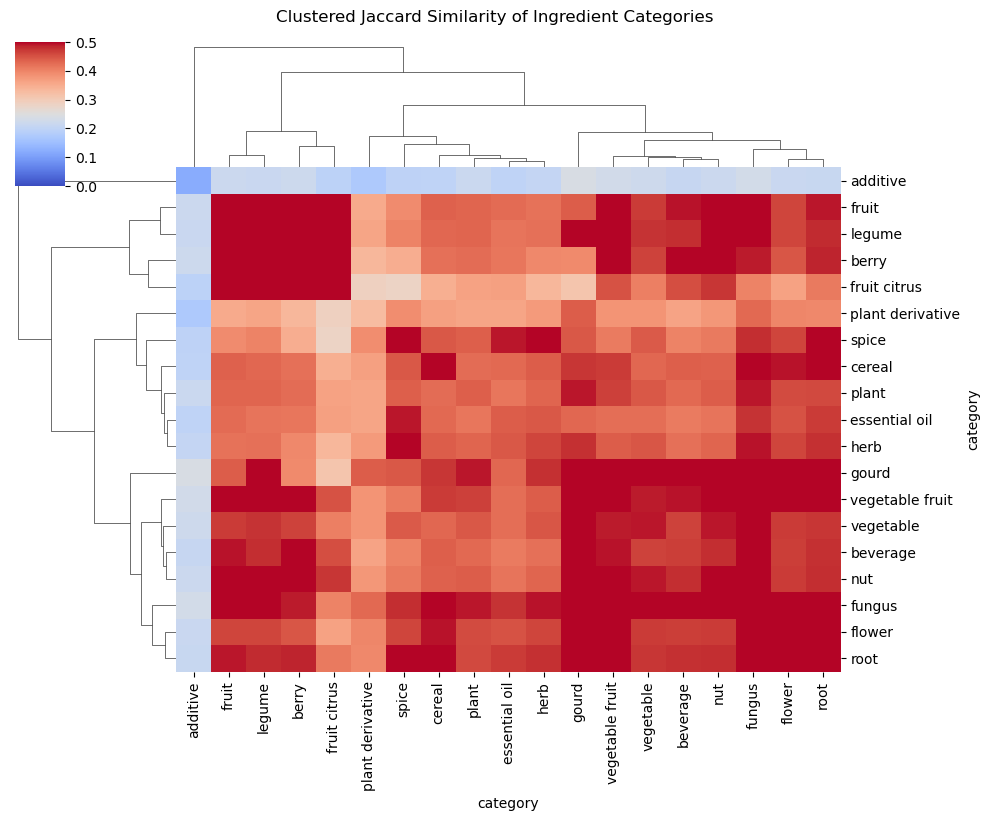

In [34]:
# --- Cluster the category-level similarity matrix ---
sns.clustermap(
    jaccard_sim_mean,
    cmap="coolwarm",
    vmin=0, vmax=0.5,
    method="ward",
    metric="euclidean",
    figsize=(10, 8)
)

plt.suptitle("Clustered Jaccard Similarity of Ingredient Categories", y=1.02)

save_path = os.path.join("output", "cat_clustered_jaccard.png")
plt.savefig(save_path, dpi=300, bbox_inches='tight')

plt.show()

In [35]:
def get_top3_categories(sim_df: pd.DataFrame) -> pd.DataFrame:
    """
    For each row in a similarity matrix, return the top 3 most similar
    categories (excluding self-similarity) and their similarity values.
    """
    df = sim_df.copy()

    # Sort columns for each row and take top 3
    top3_cols = df.apply(lambda row: row.nlargest(3).index.tolist(), axis=1)
    top3_vals = df.apply(lambda row: row.nlargest(3).values.tolist(), axis=1)

    # Build output DataFrame
    out = pd.DataFrame({
        "top1_category": top3_cols.str[0],
        "top1_jaccard": top3_vals.str[0],
        "top2_category": top3_cols.str[1],
        "top2_jaccard": top3_vals.str[1],
        "top3_category": top3_cols.str[2],
        "top3_jaccard": top3_vals.str[2],
    }, index=sim_df.index)

    return out


# ✅ Apply to your Jaccard similarity matrix
top3_jaccard = get_top3_categories(jaccard_sim_mean)

# top3_jaccard.to_excel("output/cat_jaccard_sim_top3.xlsx")


In [36]:
import pandas as pd

def to_two_level_cols(df: pd.DataFrame) -> pd.DataFrame:
    """
    Convert columns like:
      top1_category, top1_jaccard, top2_category, top2_jaccard, top3_category, top3_jaccard
    into a MultiIndex:
      ('Top 1','category'), ('Top 1','jaccard similarity'), ...
    """
    rank_map = {"top1": "Top 1", "top2": "Top 2", "top3": "Top 3"}
    new_cols = []

    for c in df.columns:
        if "_" in c:
            rank, field = c.split("_", 1)
            top = rank_map.get(rank, rank.title())
            bottom = "jaccard similarity" if field.lower().startswith("jaccard") else field.lower()
            new_cols.append((top, bottom))
        else:
            # fallback if any extra columns
            new_cols.append(("Other", c))

    out = df.copy()
    out.columns = pd.MultiIndex.from_tuples(new_cols, names=["rank", "Reference Category"])
    return out

# ✅ Apply
top3_jaccard_mi = to_two_level_cols(top3_jaccard)

# Example access:
# top3_jaccard_mi[('Top 2', 'category')]
# top3_jaccard_mi[('Top 3', 'jaccard similarity')]
top3_jaccard_mi.to_excel("output/cat_jaccard_sim_top3.xlsx")

top3_jaccard_mi


rank                       Top 1                            Top 2  \
Reference Category      category jaccard similarity      category   
category                                                            
additive                   gourd           0.239211        fungus   
berry                      berry           0.768884  fruit citrus   
beverage                  fungus           0.522381         gourd   
cereal                    fungus           0.546280          root   
essential oil              spice           0.490465        fungus   
flower                    fungus           0.572722        flower   
fruit                      berry           0.659845  fruit citrus   
fruit citrus        fruit citrus           0.780000         berry   
fungus                    fungus           0.645333         gourd   
gourd                      gourd           0.795918        fungus   
herb                       spice           0.504959        fungus   
legume                     berry           0.578615         fruit   
nut                        gourd           0.559982           nut   
plant                     fungus           0.491853         gourd   
plant derivative           gourd           0.439881        fungus   
root                      fungus           0.571672          root   
spice                      spice           0.628053          herb   
vegetable                  gourd           0.569368        fungus   
vegetable fruit           fungus           0.565833         gourd   

rank                                             Top 3                     
Reference Category jaccard similarity         category jaccard similarity  
category                                                                   
additive                     0.230250  vegetable fruit           0.226693  
berry                        0.735659            fruit           0.659845  
beverage                     0.511338            berry           0.507401  
cereal                       0.504248           cereal           0.499549  
essential oil                0.475302             root           0.470568  
flower                       0.547454            gourd           0.536706  
fruit                        0.621611            fruit           0.598490  
fruit citrus                 0.735659            fruit           0.621611  
fungus                       0.619048           flower           0.572722  
gourd                        0.619048        vegetable           0.569368  
herb                         0.492211            gourd           0.478279  
legume                       0.543583     fruit citrus           0.532246  
nut                          0.537278           fungus           0.530872  
plant                        0.490308  vegetable fruit           0.466777  
plant derivative             0.429233           flower           0.397292  
root                         0.544862           flower           0.519832  
spice                        0.504959             root           0.503880  
vegetable                    0.521218        vegetable           0.491605  
vegetable fruit              0.565476  vegetable fruit           0.562500

In [37]:
from sklearn.metrics.pairwise import cosine_distances
import pandas as pd

# desc = list of descriptor column names
# df1 = your main dataframe (columns: desc + ['db','category'])

# 1. Split into flavor_db and local
df_flavor = df1[df1["db"] == "flavor_db"].copy(deep=True)
df_local  = df1[df1["db"] != "flavor_db"].copy(deep=True)

# 2. Find categories that exist in both
shared_categories = set(df_flavor["category"]) & set(df_local["category"])

# 3. Prepare output list
results = []

# 4. Compute cosine distance for each shared category
for cat in shared_categories:
    v1 = df_flavor[df_flavor["category"] == cat][desc].mean().values
    v2 = df_local[df_local["category"] == cat][desc].mean().values
    
    dist = cosine_distances([v1], [v2])[0][0]
    
    results.append({
        "category": cat,
        "cosine_distance": dist
    })

# 5. Convert to DataFrame
distance_df = pd.DataFrame(results).sort_values("cosine_distance")
distance_df


,category,cosine_distance
7,fungus,0.049607
3,vegetable,0.111212
8,root,0.116891
0,plant,0.147569
1,cereal,0.220139
5,fruit,0.305817
6,herb,0.322721
9,flower,0.399630
4,beverage,0.493563
2,additive,0.544294


In [38]:
from sklearn.metrics.pairwise import cosine_distances
import pandas as pd

# Split two supercategories
df_flavor = df1[df1["db"] == "flavor_db"]
df_local  = df1[df1["db"] != "flavor_db"]

# Shared categories
shared_categories = set(df_flavor["category"]) & set(df_local["category"])

# Compute FlavorDB vs Local distance
between_results = []
for cat in shared_categories:
    v_flavor = df_flavor[df_flavor["category"] == cat][desc].mean().values
    v_local  = df_local[df_local["category"] == cat][desc].mean().values
    dist = cosine_distances([v_flavor], [v_local])[0][0]
    
    between_results.append({
        "category": cat,
        "between_distance": dist
    })

between_df = pd.DataFrame(between_results)

def intra_category_distances(df, desc):
    results = []
    for cat, group in df.groupby("category"):
        X = group[desc].values
        
        # Skip categories with <2 samples
        if len(X) < 2:
            continue
        
        # compute full distance matrix
        D = cosine_distances(X, X)
        
        # take upper triangle (excluding diag)
        triu = D[np.triu_indices_from(D, k=1)]
        results.append({
            "category": cat,
            "within_distance_mean": triu.mean(),
            "within_distance_std": triu.std(),
            "n_samples": len(X)
        })
    return pd.DataFrame(results)

within_flavor = intra_category_distances(df_flavor, desc)
within_local  = intra_category_distances(df_local, desc)

within_flavor["db"] = "flavor_db"
within_local["db"]  = "local"

within_df = pd.concat([within_flavor, within_local], ignore_index=True)

comparison = (
    between_df
    .merge(within_df[within_df["db"]=="flavor_db"][["category","within_distance_mean"]]
           .rename(columns={"within_distance_mean":"within_flavor_db"}),
           on="category", how="left")
    .merge(within_df[within_df["db"]=="local"][["category","within_distance_mean"]]
           .rename(columns={"within_distance_mean":"within_local"}),
           on="category", how="left")
)

comparison = comparison.sort_values("between_distance")
comparison


,category,between_distance,within_flavor_db,within_local
7,fungus,0.049607,0.499817,0.431831
3,vegetable,0.111212,0.557598,0.546744
8,root,0.116891,0.560311,0.580865
0,plant,0.147569,0.649688,0.580397
1,cereal,0.220139,0.527749,0.381171
5,fruit,0.305817,0.598099,0.676971
6,herb,0.322721,0.659629,0.237951
9,flower,0.399630,0.645800,0.660240
4,beverage,0.493563,0.673268,NaN
2,additive,0.544294,0.774384,0.504392


In [39]:
# Compare shared categories between local and flavordb using jaccard

# Compute Jaccard similarity matrix
df2 = df1.loc[df1['db'] == 'local']
local_sim = jaccard_similarity_matrix(df2[desc])

# Average similarity per category
local_sim['category'] = df2['category'].values
local_sim_mean = local_sim.groupby('category').mean()
local_sim_mean = local_sim_mean.T
local_sim_mean['category'] = df2['category'].values
local_sim_mean = local_sim_mean.groupby('category').mean()
local_sim_mean

# Compute Jaccard similarity matrix
df2 = df1.loc[df1['db'] != 'local']
flavor_sim = jaccard_similarity_matrix(df2[desc])

# Average similarity per category
flavor_sim['category'] = df2['category'].values
flavor_sim_mean = flavor_sim.groupby('category').mean()
flavor_sim_mean = flavor_sim_mean.T
flavor_sim_mean['category'] = df2['category'].values
flavor_sim_mean = flavor_sim_mean.groupby('category').mean()
flavor_sim_mean

category,additive,berry,beverage,cereal,essential oil,flower,fruit,fruit citrus,fungus,gourd,herb,legume,nut,plant,plant derivative,root,spice,vegetable,vegetable fruit
category,,,,,,,,,,,,,,,,,,,
additive,0.082080,0.178186,0.158233,0.144023,0.143938,0.159407,0.172428,0.160533,0.164909,0.166190,0.150235,0.162261,0.160128,0.163319,0.123700,0.138037,0.132187,0.156276,0.172500
berry,0.178186,0.768884,0.516105,0.412724,0.415062,0.443282,0.686769,0.735659,0.460817,0.393411,0.410488,0.578615,0.528190,0.489845,0.334729,0.428790,0.349550,0.439771,0.515019
beverage,0.158233,0.516105,0.479167,0.438391,0.412151,0.456852,0.503632,0.463000,0.504545,0.517857,0.434526,0.486703,0.485321,0.473870,0.364625,0.436065,0.401733,0.458760,0.498958
cereal,0.144023,0.412724,0.438391,0.499128,0.424379,0.459195,0.425330,0.335805,0.517450,0.473727,0.448569,0.424513,0.433090,0.467369,0.363621,0.440773,0.439011,0.421741,0.467672
essential oil,0.143938,0.415062,0.412151,0.424379,0.440521,0.417528,0.425752,0.366744,0.444538,0.430509,0.445923,0.416582,0.416741,0.446546,0.360631,0.428252,0.490465,0.416356,0.423256
flower,0.159407,0.443282,0.456852,0.459195,0.417528,0.524691,0.446022,0.366111,0.521380,0.530423,0.446877,0.448873,0.458333,0.470947,0.377963,0.432716,0.410815,0.450497,0.502315
fruit,0.172428,0.686769,0.503632,0.425330,0.425752,0.446022,0.636087,0.652490,0.471437,0.423280,0.426902,0.552371,0.513042,0.490169,0.347156,0.438797,0.386642,0.446939,0.506893
fruit citrus,0.160533,0.735659,0.463000,0.335805,0.366744,0.366111,0.652490,0.780000,0.378182,0.310714,0.347157,0.532246,0.474231,0.424296,0.287750,0.363519,0.282000,0.379024,0.450000
fungus,0.164909,0.460817,0.504545,0.517450,0.444538,0.521380,0.471437,0.378182,0.590909,0.603896,0.481610,0.488801,0.506818,0.515051,0.405909,0.479545,0.442182,0.497118,0.549242


In [40]:
# Compute similarity between ingredients within flavord vs local - should do by catgories though
# Compute Jaccard similarity matrix
jaccard_sim = jaccard_similarity_matrix(df1[desc])

# Average similarity per db
jaccard_sim['db'] = df1['db'].values
# jaccard_sim['category'] = df1['category'].values
jaccard_sim_mean = jaccard_sim.groupby('db').mean()
jaccard_sim_mean = jaccard_sim_mean.T
jaccard_sim_mean['db'] = df1['db'].values
jaccard_sim_mean = jaccard_sim_mean.groupby('db').mean()

jaccard_sim_mean


db,flavor_db,local
db,,
flavor_db,0.434770,0.436443
local,0.436443,0.469945


In [41]:
# Compute similarity between ingredients within flavord vs local  
# Could maybe do a heatmap or cluster map of that 

# Compute Jaccard similarity matrix
jaccard_sim = jaccard_similarity_matrix(df1[desc])

# Average similarity per db
jaccard_sim['db'] = df1['db'].values
jaccard_sim['category'] = df1['category'].values

shared_cat = jaccard_sim.loc[jaccard_sim['db'] == 'local', 'category'].unique()

rows =[]
for cat in shared_cat:
    df2 = jaccard_sim.loc[jaccard_sim['category'] == cat]
    df2 = df2.drop(columns= 'category')
    idx = df2.index.to_list() + ['db']

    df2= df2[idx]
    jaccard_sim_mean = df2.groupby('db').mean()
    jaccard_sim_mean = jaccard_sim_mean.T
    jaccard_sim_mean['db'] = df2['db'].values
    jaccard_sim_mean = jaccard_sim_mean.groupby('db').mean()

    # get counts
    flavor_count = df2['db'].value_counts()['flavor_db']
    local_count = df2['db'].value_counts()['local']

    # Extract group diff
    flavor_local = jaccard_sim_mean.loc[jaccard_sim_mean.index == 'flavor_db']['local'].values[0]
    flavor_flavor = jaccard_sim_mean.loc[jaccard_sim_mean.index == 'flavor_db']['flavor_db'].values[0]
    local_local = jaccard_sim_mean.loc[jaccard_sim_mean.index == 'local']['local'].values[0]

    rows.append({
        "category": cat,
        "flavor_vs_local": flavor_local,
        "flavor_vs_flavor": flavor_flavor,
        "local_vs_local": local_local,
        'flavor_count' : flavor_count,
        'local_count' : local_count
    })

# Final comparison table
comparison_df = pd.DataFrame(rows)

comparison_df = comparison_df[comparison_df["local_count"] >= 3].copy()

comparison_df.to_excel(f"output/local_flavordb_jaccard_distance.xlsx", index=False)
comparison_df



,category,flavor_vs_local,flavor_vs_flavor,local_vs_local,flavor_count,local_count
0,plant,0.428698,0.494436,0.426572,45,68
1,fungus,0.629870,0.590909,0.703231,11,14
3,vegetable,0.489246,0.489391,0.539945,41,11
4,root,0.504716,0.446502,0.595709,18,43
5,fruit,0.432785,0.636087,0.535802,81,9
6,herb,0.412691,0.468410,0.814815,51,6
7,additive,0.140476,0.082080,0.470068,25,7
9,flower,0.543210,0.524691,0.777778,9,3


# Umap

c:\Users\jpcle8\AppData\Local\miniconda3\envs\native\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\jpcle8\AppData\Local\miniconda3\envs\native\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


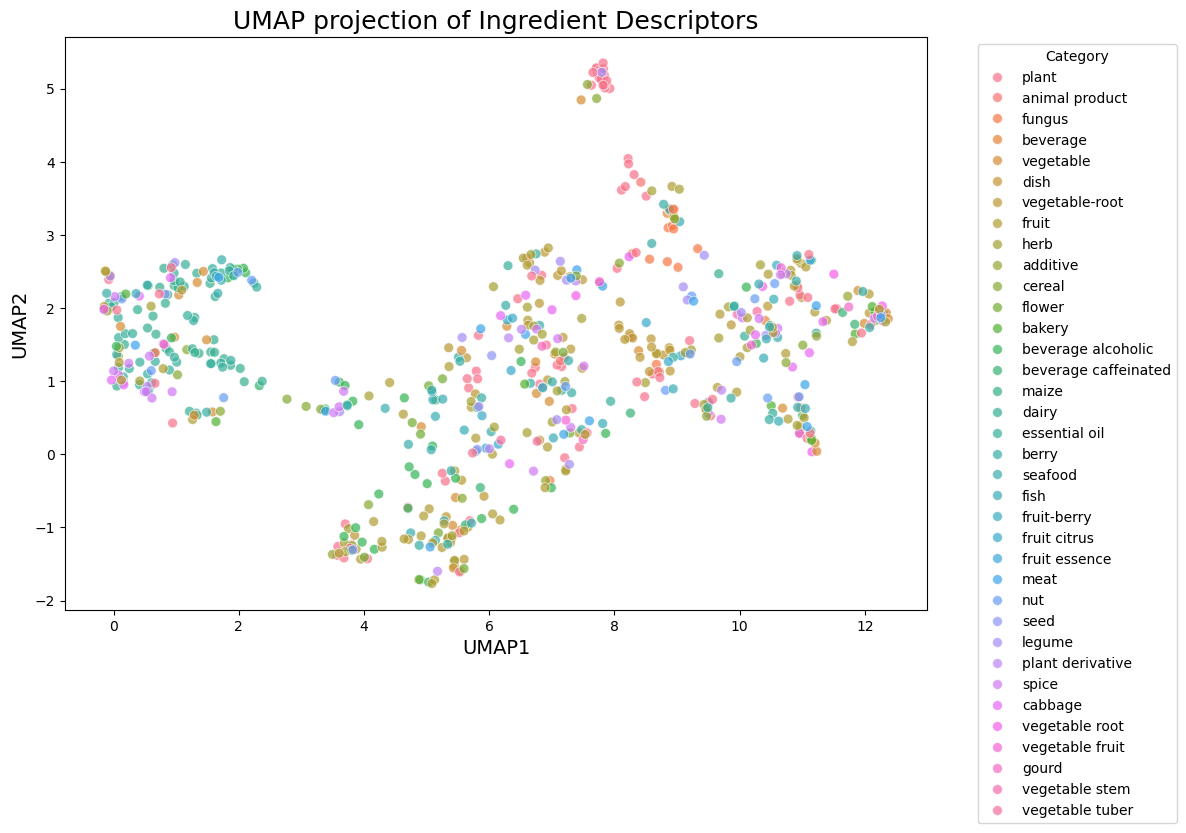

In [42]:
import umap
import matplotlib.pyplot as plt
import seaborn as sns

local = merged_df[merged_df['db'] == 'local']
local_names = local['Nom scientifique'].to_list()

df1_local = df1[df1['Nom scientifique'].isin(local_names)]
df1_local

# Separate features and the category for coloring
df_features = df1[desc]
# df_features = df1_local.drop(columns=['Nom scientifique'])
df_features = df_features.drop(columns=[col for col in df_features.columns if "cat_" in col])
categories = merged_df['category'] # Use the category from the merged_df before dropping columns

# Apply UMAP
reducer = umap.UMAP(random_state=42)
umap_embedding = reducer.fit_transform(df_features)

# Create a DataFrame for plotting
umap_df = pd.DataFrame(umap_embedding, columns=['UMAP1', 'UMAP2'])
umap_df['category'] = categories

# Plot the UMAP embedding
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='UMAP1',
    y='UMAP2',
    hue='category',
    data=umap_df,
    s=50,
    alpha=0.7
)
plt.title('UMAP projection of Ingredient Descriptors', fontsize=18)
plt.xlabel('UMAP1', fontsize=14)
plt.ylabel('UMAP2', fontsize=14)
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

c:\Users\jpcle8\AppData\Local\miniconda3\envs\native\lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


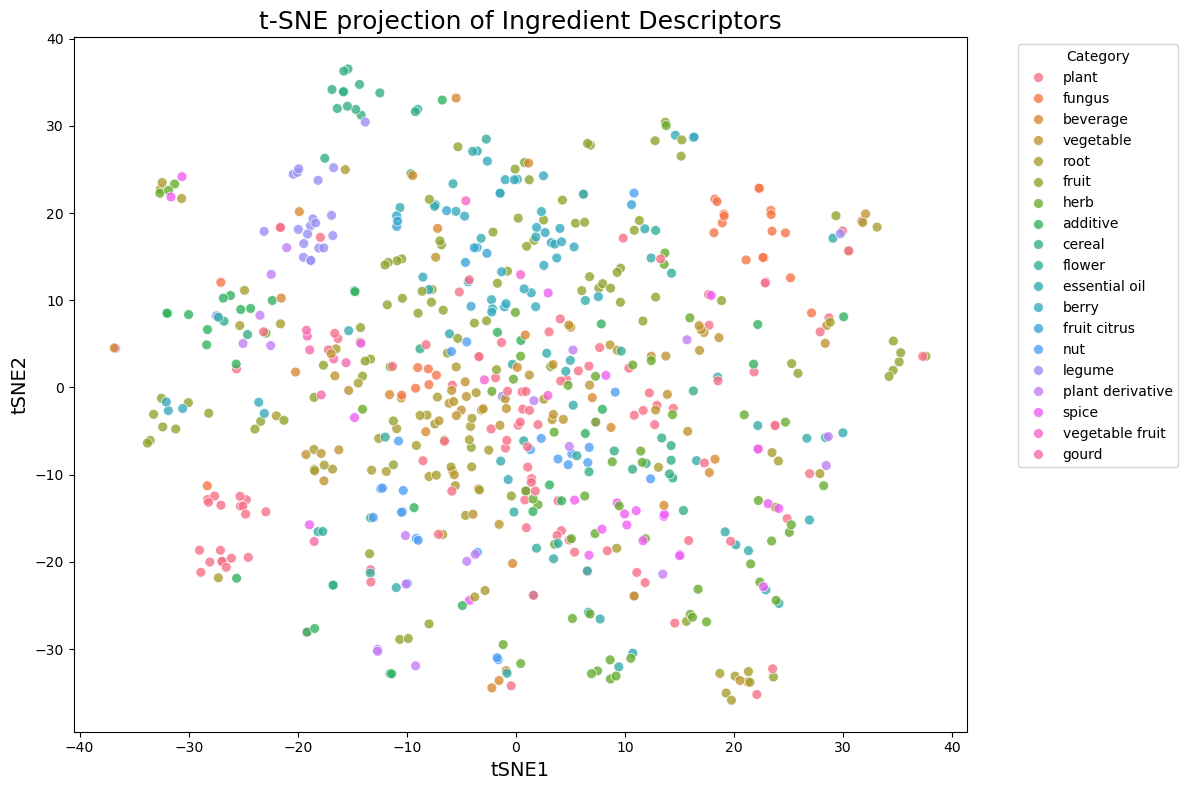

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# --- Build feature matrix (drop identifiers and one-hot category columns) ---
df_features = df1[desc]
df_features = df_features.drop(columns=[c for c in df_features.columns if "cat_" in c], errors='ignore')

# Keep only numeric columns (t-SNE requires numbers)
df_features = df_features.select_dtypes(include=[np.number])

# Handle NaNs
df_features = df_features.fillna(0.0)

# Optional: scale features (recommended for t-SNE)
X = StandardScaler().fit_transform(df_features.values)

# --- Align categories from merged_df to df1 rows ---
name_series = df1['Nom scientifique']
categories = df1['category']

# --- Fit t-SNE ---
tsne = TSNE(
    n_components=2,
    perplexity=min(30, max(5, (len(df_features) - 1) // 3)),  # decent auto heuristic
    learning_rate='auto',
    init='pca',
    metric='euclidean',
    random_state=42,
)
tsne_embedding = tsne.fit_transform(X)

# --- Prepare DataFrame for plotting ---
tsne_df = pd.DataFrame(tsne_embedding, columns=['tSNE1', 'tSNE2'])
tsne_df['category'] = categories.values

# --- Plot ---
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=tsne_df,
    x='tSNE1',
    y='tSNE2',
    hue='category',
    s=50,
    alpha=0.8
)
plt.title('t-SNE projection of Ingredient Descriptors', fontsize=18)
plt.xlabel('tSNE1', fontsize=14)
plt.ylabel('tSNE2', fontsize=14)
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

save_path = os.path.join("output", "cat_tsne.png")
plt.savefig(save_path, dpi=300, bbox_inches='tight')

plt.show()


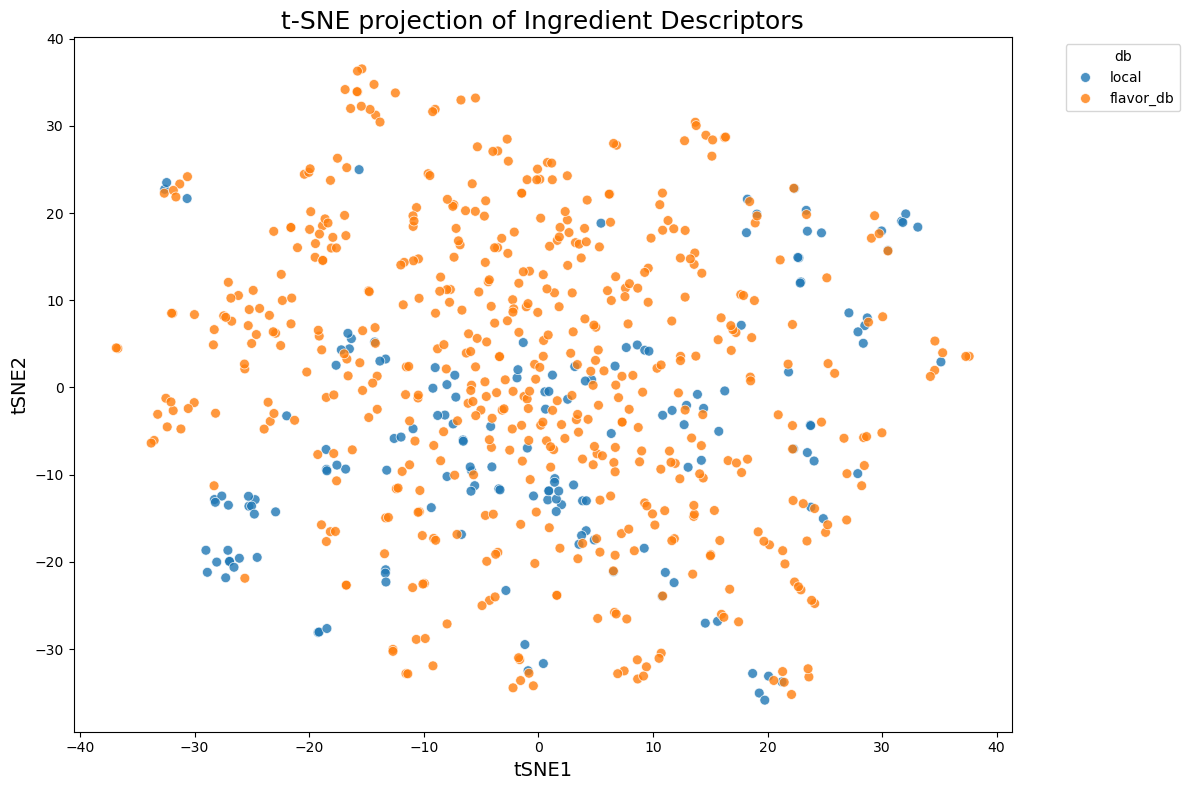

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# --- Build feature matrix (drop identifiers and one-hot db columns) ---
df_features = df1[desc]
df_features = df_features.drop(columns=[c for c in df_features.columns if "cat_" in c], errors='ignore')

# Keep only numeric columns (t-SNE requires numbers)
df_features = df_features.select_dtypes(include=[np.number])

# Handle NaNs
df_features = df_features.fillna(0.0)

# Optional: scale features (recommended for t-SNE)
X = StandardScaler().fit_transform(df_features.values)

# --- Align categories from merged_df to df1 rows ---
name_series = df1['Nom scientifique']
categories = df1['db']

# --- Fit t-SNE ---
tsne = TSNE(
    n_components=2,
    perplexity=min(30, max(5, (len(df_features) - 1) // 3)),  # decent auto heuristic
    learning_rate='auto',
    init='pca',
    metric='euclidean',
    random_state=42,
)
tsne_embedding = tsne.fit_transform(X)

# --- Prepare DataFrame for plotting ---
tsne_df = pd.DataFrame(tsne_embedding, columns=['tSNE1', 'tSNE2'])
tsne_df['db'] = categories.values

# --- Plot ---
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=tsne_df,
    x='tSNE1',
    y='tSNE2',
    hue='db',
    s=50,
    alpha=0.8
)
plt.title('t-SNE projection of Ingredient Descriptors', fontsize=18)
plt.xlabel('tSNE1', fontsize=14)
plt.ylabel('tSNE2', fontsize=14)
plt.legend(title='db', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

save_path = os.path.join("output", "db_tsne.png")
plt.savefig(save_path, dpi=300, bbox_inches='tight')

plt.show()

c:\Users\jpcle8\AppData\Local\miniconda3\envs\native\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


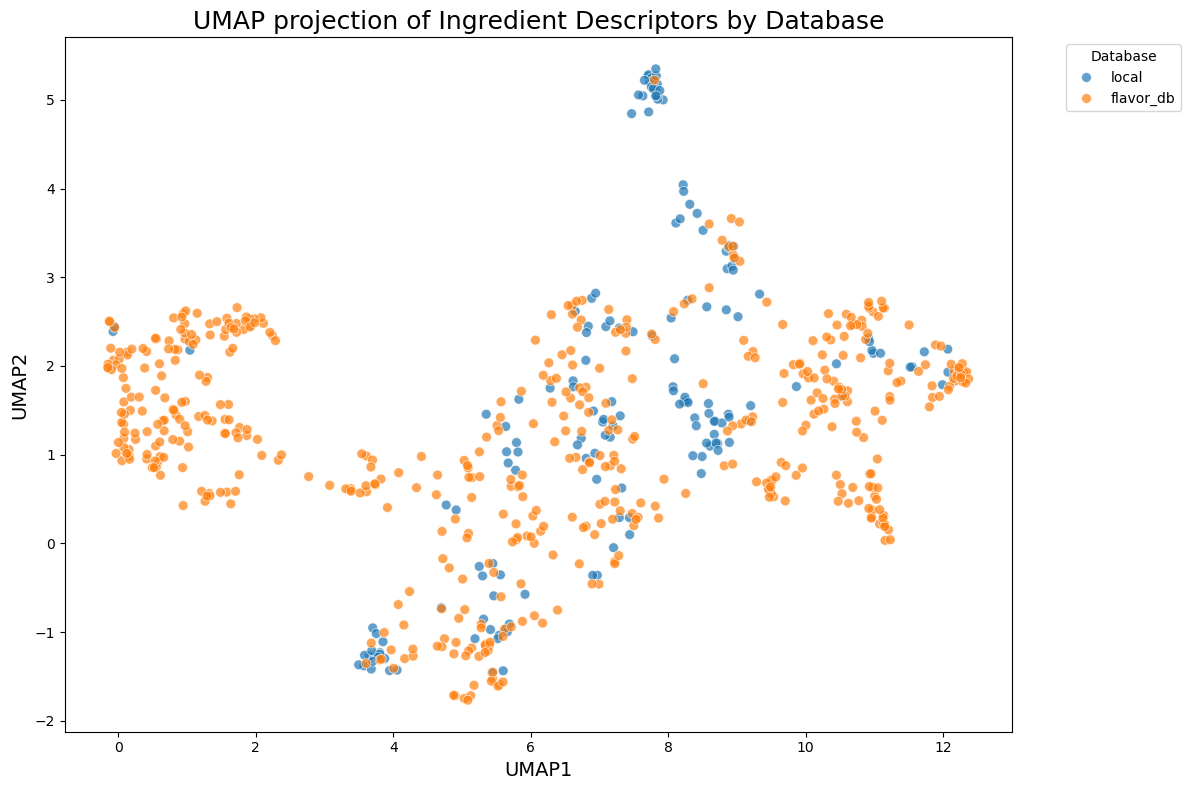

In [45]:
# Separate features and the category for coloring
df_features = df1[desc]
databases = merged_df['db'] # Use the 'db' column from the merged_df for coloring

# Apply UMAP
reducer = umap.UMAP(random_state=42)
umap_embedding = reducer.fit_transform(df_features)

# Create a DataFrame for plotting
umap_df = pd.DataFrame(umap_embedding, columns=['UMAP1', 'UMAP2'])
umap_df['database'] = databases

# Plot the UMAP embedding
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='UMAP1',
    y='UMAP2',
    hue='database',
    data=umap_df,
    s=50,
    alpha=0.7
)
plt.title('UMAP projection of Ingredient Descriptors by Database', fontsize=18)
plt.xlabel('UMAP1', fontsize=14)
plt.ylabel('UMAP2', fontsize=14)
plt.legend(title='Database', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# KNN

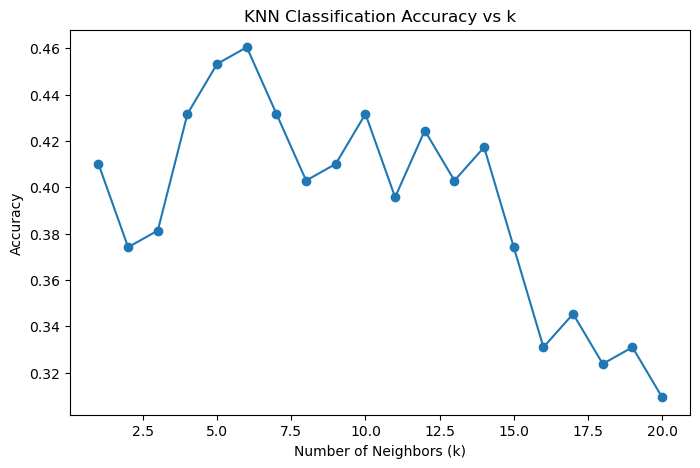

In [46]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# --- Features and labels ---
X = df1[desc].values
y = df1['category']

# --- Split train/test ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# --- Scale features (important for distance-based models) ---
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# --- Test different k values ---
k_values = range(1, 21)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    accuracies.append(accuracy_score(y_test, y_pred))

# --- Plot accuracy vs k ---
plt.figure(figsize=(8, 5))
plt.plot(k_values, accuracies, marker='o')
plt.title("KNN Classification Accuracy vs k")
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Accuracy")
plt.show()


c:\Users\jpcle8\AppData\Local\miniconda3\envs\native\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\jpcle8\AppData\Local\miniconda3\envs\native\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\jpcle8\AppData\Local\miniconda3\envs\native\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\jpcle8\AppData\Local\miniconda3\envs\native

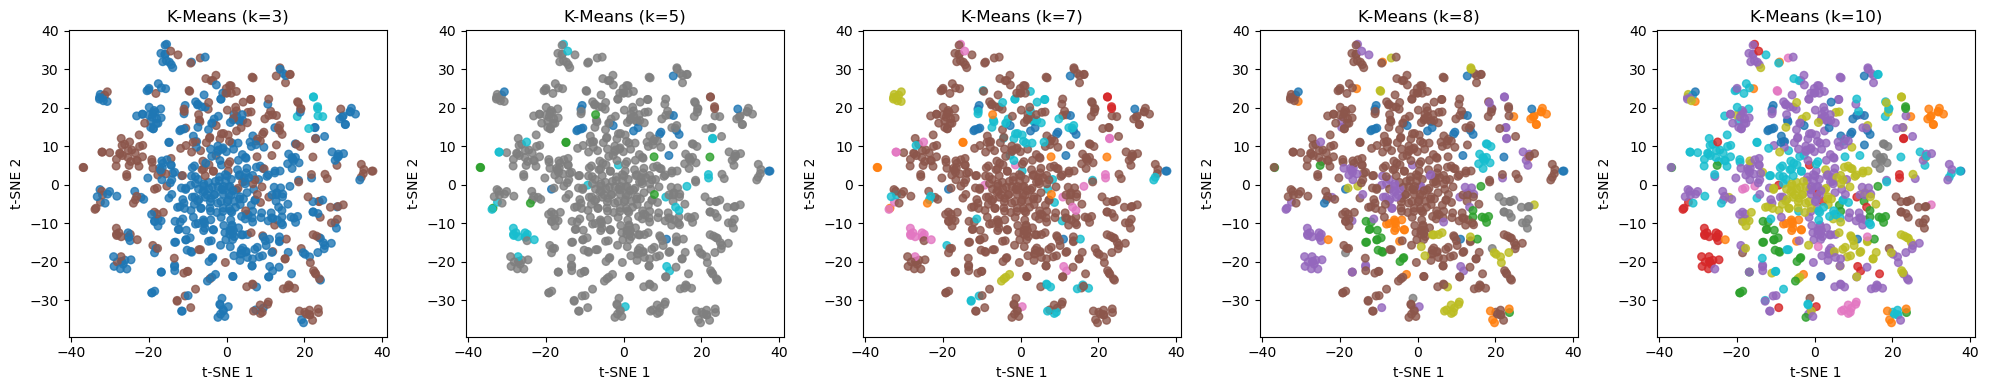

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# --- Prepare feature matrix ---
X = df1[desc].values

# --- Standardize features (important for clustering) ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- Try several k values ---
k_values = [3, 5, 7, 8, 10]

# --- Run t-SNE once (expensive) ---
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_embedded = tsne.fit_transform(X_scaled)

# --- Plot clusters for each k ---
fig, axes = plt.subplots(1, len(k_values), figsize=(4*len(k_values), 4))

for ax, k in zip(axes, k_values):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = kmeans.fit_predict(X_scaled)
    
    sc = ax.scatter(
        X_embedded[:, 0], X_embedded[:, 1],
        c=labels, cmap='tab10', s=30, alpha=0.8
    )
    ax.set_title(f"K-Means (k={k})")
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")

plt.tight_layout()
plt.show()

In [48]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# --- Prepare data ---
X = df1[desc].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- Run K-Means clustering with k=7 ---
k = 7
kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
labels = kmeans.fit_predict(X_scaled)

# --- Add cluster labels to df1 ---
df1['cluster'] = labels

# --- Compute cluster centroids in original feature space ---
centroids = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=desc
)

# --- For each cluster, find top descriptors (highest centroid values) ---
top_desc_per_cluster = {}

for i in range(k):
    centroid = centroids.iloc[i]
    top_features = centroid.sort_values(ascending=False).head(10).index.tolist()
    top_desc_per_cluster[i] = top_features

# --- Display results ---
for cluster_id, top_feats in top_desc_per_cluster.items():
    print(f"\n🧭 Cluster {cluster_id}: Top descriptors")
    print(", ".join(top_feats))



🧭 Cluster 0: Top descriptors
svd_056, svd_002, svd_054, svd_058, svd_052, svd_047, svd_016, svd_025, svd_033, svd_071

🧭 Cluster 1: Top descriptors
svd_091, svd_084, svd_056, svd_069, svd_080, svd_070, svd_060, svd_041, svd_020, svd_013

🧭 Cluster 2: Top descriptors
svd_073, svd_074, svd_022, svd_019, svd_066, svd_068, svd_011, svd_040, svd_083, svd_052

🧭 Cluster 3: Top descriptors
svd_001, svd_032, svd_062, svd_092, svd_006, svd_040, svd_049, svd_063, svd_010, svd_083

🧭 Cluster 4: Top descriptors
svd_053, svd_005, svd_061, svd_042, svd_007, svd_044, svd_030, svd_008, svd_066, svd_012

🧭 Cluster 5: Top descriptors
svd_060, svd_100, svd_097, svd_074, svd_098, svd_003, svd_052, svd_099, svd_027, svd_048

🧭 Cluster 6: Top descriptors
svd_002, svd_041, svd_031, svd_061, svd_014, svd_026, svd_047, svd_093, svd_011, svd_027


c:\Users\jpcle8\AppData\Local\miniconda3\envs\native\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


In [49]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# --- params ---
k = 7
top_n = 5                       # how many nearest ingredients to list per cluster
feature_cols = desc             # your descriptor columns

# --- scale & cluster (if not already done) ---
X = df1[feature_cols].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
labels = kmeans.fit_predict(X_scaled)
centers = kmeans.cluster_centers_

df1['cluster'] = labels

# --- choose a display name column if available ---
name_col = 'name' if 'name' in df1.columns else ('Nom scientifique' if 'Nom scientifique' in df1.columns else None)
def get_label(idx):
    if name_col is not None:
        return df1.iloc[idx][name_col]
    return df1.index[idx]

# --- compute distances to own cluster centroid & pick top_n nearest ---
nearest_per_cluster = {}
nearest_rows = []  # for a tidy DataFrame output

for c in range(k):
    idx_c = np.where(labels == c)[0]
    if len(idx_c) == 0:
        nearest_per_cluster[c] = []
        continue

    Xc = X_scaled[idx_c]
    centroid = centers[c]

    # Euclidean distances in the scaled space
    dists = np.linalg.norm(Xc - centroid, axis=1)
    order = np.argsort(dists)[:min(top_n, len(idx_c))]

    closest_indices = idx_c[order]
    closest_names = [get_label(i) for i in closest_indices]
    closest_dists = dists[order]

    nearest_per_cluster[c] = list(zip(closest_names, closest_indices, closest_dists))

    # collect rows for a tidy table
    for name, idx_global, dist in zip(closest_names, closest_indices, closest_dists):
        nearest_rows.append({
            "cluster": c,
            "ingredient": name,
            "row_index": idx_global,
            "distance_to_centroid": float(dist)
        })

# --- dict result ---
# nearest_per_cluster: { cluster_id: [(ingredient_name, row_index, distance), ...], ... }

# --- tidy DataFrame result (sorted) ---
nearest_df = pd.DataFrame(nearest_rows).sort_values(["cluster", "distance_to_centroid"])
print(nearest_df)


    cluster               ingredient  row_index  distance_to_centroid
0         0                 Cinnamon        380              6.795814
1         0            Silver linden        453              6.958630
2         0             Passionfruit        259              7.139035
3         0          Mandarin Orange        303              7.555507
4         0                   Loquat        249              8.174247
5         1              Fruit juice        664              8.139019
6         1                    Syrup        638              8.722315
7         1         Chocolate spread        639             10.320596
8         1                    Dates        238             10.913295
9         1                   Spread        660             11.430150
10        2     Morchella crassipes          37              7.239960
11        2                 Mushroom        307              7.367195
12        2       Morchella esadenla         38              7.690682
13        2         

c:\Users\jpcle8\AppData\Local\miniconda3\envs\native\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


# Cosine similarity comparisons

In [50]:
# Compare different categories in distance - not very useful

# def weighted_jaccard_similarity(df: pd.DataFrame) -> pd.DataFrame:
#     """
#     Compute the Weighted Jaccard similarity matrix for a numeric dataframe.
#     Rows = items, Columns = features.
#     """
#     X = df.to_numpy(dtype=float)
#     n = X.shape[0]
    
#     sim = np.zeros((n, n))
    
#     for i in range(n):
#         for j in range(i, n):
#             min_sum = np.minimum(X[i], X[j]).sum()
#             max_sum = np.maximum(X[i], X[j]).sum()
#             sim_val = min_sum / max_sum if max_sum != 0 else 0
#             sim[i, j] = sim_val
#             sim[j, i] = sim_val  # symmetric

#     return pd.DataFrame(sim, index=df.index, columns=df.index)

# # --- Usage ---
# # Remove non-numeric columns if needed
# df2_numeric = df2.select_dtypes(include=[np.number])

# wj_sim_matrix = weighted_jaccard_similarity(df2_numeric)
# wj_sim_matrix

# import seaborn as sns
# import matplotlib.pyplot as plt

# plt.figure(figsize=(10, 8))
# sns.heatmap(wj_sim_matrix, cmap="viridis", annot=False)
# plt.title("Weighted Jaccard Similarity Matrix")
# plt.show()


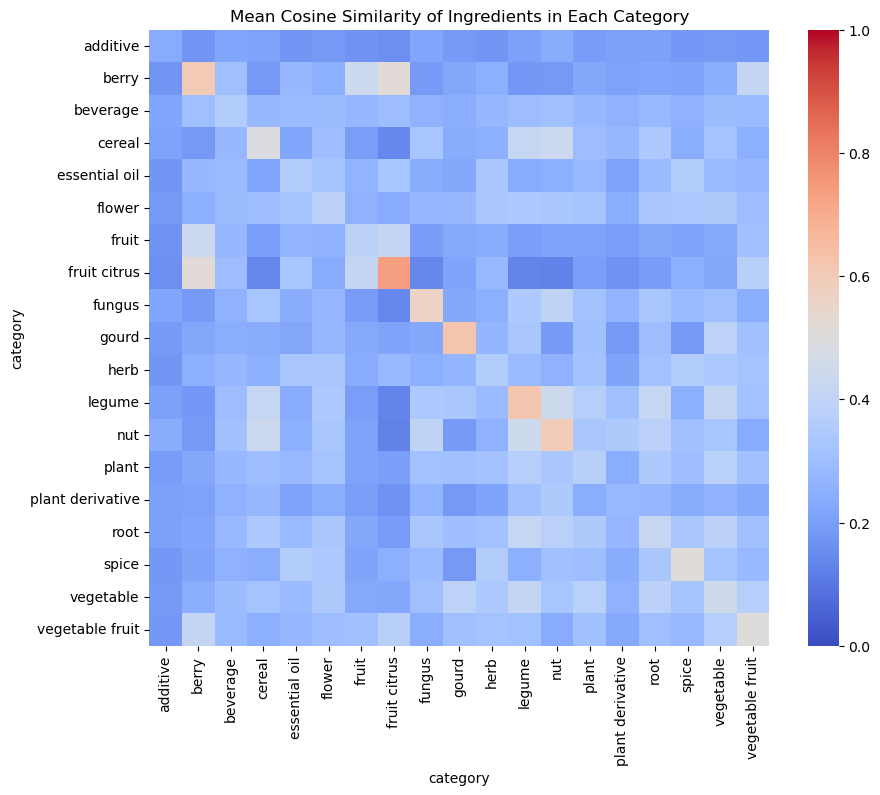

In [51]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def cosine_similarity_matrix(df_num: pd.DataFrame) -> pd.DataFrame:
    """
    Compute cosine similarity for all pairs of rows in a numeric DataFrame.
    """
    X = df_num.to_numpy(dtype=float)
    n = X.shape[0]
    sim = np.zeros((n, n), dtype=float)

    for i in range(n):
        for j in range(i, n):
            dot = np.dot(X[i], X[j])
            norm_i = np.linalg.norm(X[i])
            norm_j = np.linalg.norm(X[j])
            sim_val = dot / (norm_i * norm_j) if norm_i != 0 and norm_j != 0 else 0
            sim[i, j] = sim_val
            sim[j, i] = sim_val

    return pd.DataFrame(sim, index=df_num.index, columns=df_num.index)


# --- Compute cosine similarity matrix ---
cosine_sim = cosine_similarity_matrix(df1[desc])

# --- Average similarity per category ---
cosine_sim['category'] = df1['category'].values
cosine_sim_mean = cosine_sim.groupby('category').mean()
cosine_sim_mean = cosine_sim_mean.T
cosine_sim_mean['category'] = df1['category'].values
cosine_sim_mean = cosine_sim_mean.groupby('category').mean()

# --- Plot ---
plt.figure(figsize=(10, 8))
sns.heatmap(cosine_sim_mean, cmap="coolwarm", vmin=0, vmax=1)
plt.title("Mean Cosine Similarity of Ingredients in Each Category")
plt.show()

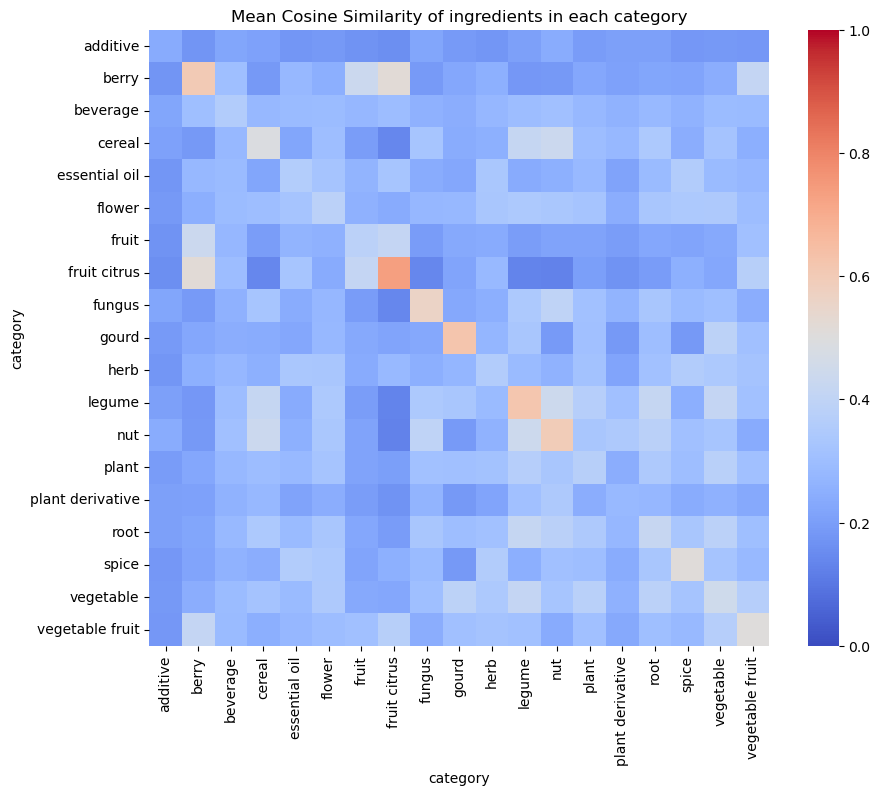

In [52]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

def cosine_similarity_matrix(df_bin: pd.DataFrame) -> pd.DataFrame:
    """
    Compute cosine similarity for all pairs of rows in a DataFrame.
    """
    X = df_bin.to_numpy(dtype=float)
    sim = cosine_similarity(X)
    return pd.DataFrame(sim, index=df_bin.index, columns=df_bin.index)


# Compute Cosine similarity matrix
cosine_sim = cosine_similarity_matrix(df1[desc])

# Average similarity per category
cosine_sim['category'] = df1['category'].values
cosine_sim_mean = cosine_sim.groupby('category').mean()
cosine_sim_mean = cosine_sim_mean.T
cosine_sim_mean['category'] = df1['category'].values
cosine_sim_mean = cosine_sim_mean.groupby('category').mean()

# Plot
plt.figure(figsize=(10, 8))
sns.heatmap(cosine_sim_mean, cmap="coolwarm", vmin=0, vmax=1)
plt.title("Mean Cosine Similarity of ingredients in each category")
plt.show()


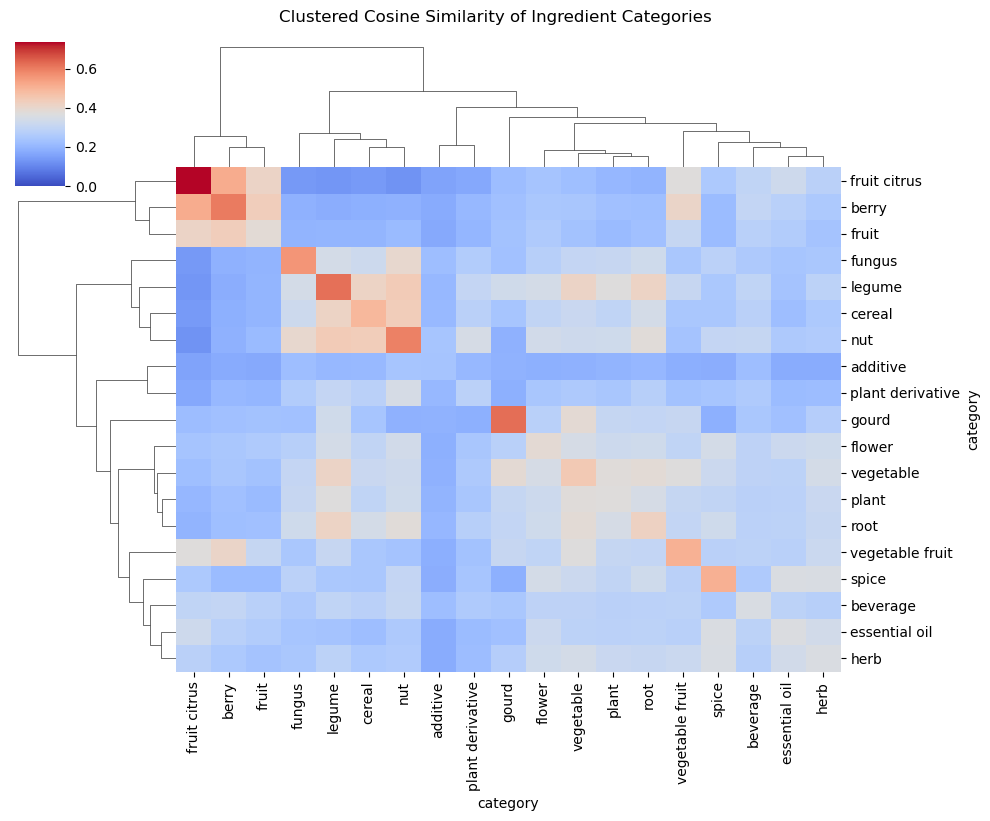

In [53]:
# --- Cluster the category-level similarity matrix ---
sns.clustermap(
    cosine_sim_mean,
    cmap="coolwarm",
    vmin=0, vmax=cosine_sim_mean.max().max(),
    method="ward",
    metric="euclidean",
    figsize=(10, 8)
)

plt.suptitle("Clustered Cosine Similarity of Ingredient Categories", y=1.02)
plt.show()

# Unsupervised learning 

In [54]:
# import numpy as np
# import pandas as pd
# import networkx as nx
# import matplotlib.pyplot as plt
# from networkx.algorithms import community

# def plot_similarity_network(sim_df: pd.DataFrame, 
#                             threshold: float = 0.15,
#                             layout: str = "spring",
#                             figsize=(12, 10)):
#     """
#     Build and plot a network graph from a category–category similarity matrix.

#     threshold : only edges with similarity >= threshold are drawn
#     layout : "spring", "kamada", "circular"
#     """
#     df = sim_df.copy()

#     # Remove self-similarity
#     np.fill_diagonal(df.values, 0)

#     # Create graph
#     G = nx.Graph()

#     # Add nodes
#     for cat in df.index:
#         G.add_node(cat)

#     # Add edges above threshold
#     for i, cat1 in enumerate(df.index):
#         for j, cat2 in enumerate(df.columns):
#             if j <= i:
#                 continue  # avoid double counting
#             weight = df.iloc[i, j]
#             if weight >= threshold:
#                 G.add_edge(cat1, cat2, weight=weight)

#     # Compute layout
#     if layout == "spring":
#         pos = nx.spring_layout(G, seed=42, k=0.4)
#     elif layout == "kamada":
#         pos = nx.kamada_kawai_layout(G)
#     elif layout == "circular":
#         pos = nx.circular_layout(G)
#     else:
#         pos = nx.spring_layout(G, seed=42)

#     # Detect communities for node colors
#     communities = list(community.greedy_modularity_communities(G))
#     community_map = {}
#     for c_id, comm in enumerate(communities):
#         for node in comm:
#             community_map[node] = c_id

#     # Node colors based on community
#     node_colors = [community_map[n] for n in G.nodes()]

#     # Edge weights for thickness
#     edges = G.edges(data=True)
#     edge_weights = [d['weight'] * 4 for _,_,d in edges]  # scale for visibility

#     # Plot
#     plt.figure(figsize=figsize)

#     nx.draw_networkx_nodes(
#         G, pos,
#         node_size=900,
#         node_color=node_colors,
#         cmap="tab20"
#     )

#     nx.draw_networkx_edges(
#         G, pos,
#         width=edge_weights,
#         alpha=0.6
#     )

#     nx.draw_networkx_labels(
#         G, pos,
#         font_size=10,
#         font_weight="bold"
#     )

#     plt.title(f"Category Similarity Network (threshold={threshold})")
#     plt.axis("off")
#     plt.show()

#     return G

# # df_to_graph = jaccard_sim.loc[:, jaccard_sim.columns != 'category'].copy(deep = True)
# df_to_graph = jaccard_sim.loc[:, jaccard_sim.columns != 'category'].copy(deep = True)

# to_drop = [954, 1030, 385, 1134]

# df_to_graph  = df_to_graph .drop(index=to_drop, columns=to_drop)

# # ✅ Build your network graph from Jaccard similarity
# G_jaccard = plot_similarity_network(df_to_graph, threshold=0.15)
